In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

**Model training pipeline for Resnet-18**

I used SimCLR, an unsupervised learning framework that learns image representations without labels. The model trains to maximise similarity between two differently augmented views of the same image while separating them from other samples.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

clr_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|██████████| 170M/170M [00:11<00:00, 14.6MB/s]


In [4]:
class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        base_model = models.resnet18(weights=None)
        self.encoder = nn.Sequential(*list(base_model.children())[:-1])
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        z = self.projector(h)
        return h, z

def nt_xent_loss(z_i, z_j, temperature=0.5):

    z = torch.cat([z_i, z_j], dim=0)
    z = F.normalize(z, dim=1)

    sim = torch.matmul(z, z.T) / temperature

    batch_size = z_i.size(0)
    labels = torch.arange(batch_size).to(z.device)
    labels = torch.cat([labels + batch_size, labels])

    mask = torch.eye(2 * batch_size, dtype=torch.bool).to(z.device)
    sim = sim.masked_fill(mask, -9e15)

    return F.cross_entropy(sim, labels)

model_path = '/content/drive/MyDrive/resnet_model_simclr.pth'
model = SimCLR().to(device)

In [5]:
import os

if os.path.exists(model_path):
    print("Loading model...")
    model.load_state_dict(torch.load(model_path, map_location=device))
else:

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

    for epoch in range(50):
        epoch_loss = 0

        for images, _ in trainloader:

            x_i = torch.stack([
                clr_transform(transforms.ToPILImage()(img.cpu()))
                for img in images
            ]).to(device)

            x_j = torch.stack([
                clr_transform(transforms.ToPILImage()(img.cpu()))
                for img in images
            ]).to(device)

            _, z_i = model(x_i)
            _, z_j = model(x_j)

            loss = nt_xent_loss(z_i, z_j)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

        torch.save(model.state_dict(), model_path)

Loading model...


In [6]:
def extract_embeddings(dataset):
    model.eval()

    embeddings, labels = [], []
    loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)

    with torch.no_grad():
        for img, label in loader:
            img = img.to(device)
            h, _ = model(img)
            h = h.view(h.size(0), -1)

            embeddings.append(h.cpu().numpy())
            labels.append(label.numpy())

    return np.concatenate(embeddings), np.concatenate(labels)

subset_size = 10000
train_subset = torch.utils.data.Subset(trainset, range(subset_size))
Z, y = extract_embeddings(train_subset)

Z_test, y_test = extract_embeddings(testset)

print("Embeddings:", Z.shape)

Embeddings: (10000, 512)


**Baselines for Accuracy Comparison**

In [9]:
def random_sampling(unlabelled, k=10):
    return np.random.choice(len(unlabelled), k, replace=False)

def entropy_sampling(model, Z, k):
    probs = model.predict_proba(Z)
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    return np.argsort(entropy)[-k:]

def margin_sampling(model, Z, k):
    probs = model.predict_proba(Z)
    sorted_probs = np.sort(probs, axis=1)
    margin = sorted_probs[:, -1] - sorted_probs[:, -2]
    return np.argsort(margin)[:k]

**Algorithm Modification and Evaluation**

I thought of implementing a diversity-aware TypiClust to address the issue of redundant sample selection. While the original method selects highly typical samples from dense regions, these samples may limit the information gained, which is a concern mentioned in the paper (3.2. Proposed Strategy: Typical Clustering (b)). To mitigate this, introducing a diversity penalty discourages selecting samples close to previously chosen points.

In [7]:
def compute_typicality(cluster_points, k=10):
    if len(cluster_points) <= k:
        k = max(1, len(cluster_points) - 1)

    nbrs = NearestNeighbors(n_neighbors=k).fit(cluster_points)
    distances, _ = nbrs.kneighbors(cluster_points)
    return 1 / (distances.mean(axis=1) + 1e-6)

In [8]:
def typiclust_selection(data, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, n_init=10).fit(data)
    labels = kmeans.labels_
    selected = []

    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        if len(indices) == 0: continue

        typicality = compute_typicality(data[indices])
        best = indices[np.argmax(typicality)]
        selected.append(best)

    return selected

In [10]:
def diversity_penalty(point, selected_points):
    if len(selected_points) == 0: return 0
    distances = np.linalg.norm(selected_points - point, axis=1)
    return 1 / (distances.mean() + 1e-6)

def typiclust_diverse(data, n_clusters, lam=0.5):
    kmeans = KMeans(n_clusters=n_clusters, n_init=10).fit(data)
    labels = kmeans.labels_
    selected_indices, selected_points = [], []

    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        if len(indices) == 0: continue

        cluster_points = data[indices]
        typicality = compute_typicality(cluster_points)

        scores = []
        for i, point in enumerate(cluster_points):
            penalty = diversity_penalty(point, np.array(selected_points))
            scores.append(typicality[i] - lam * penalty)

        best_idx = indices[np.argmax(scores)]
        selected_indices.append(best_idx)
        selected_points.append(data[best_idx])

    return selected_indices

In [11]:
labelled_rand = []
unlabelled_rand = list(range(len(Z)))
accuracies_rand = []

for iteration in range(10):

    chosen = np.random.choice(len(unlabelled_rand), 10, replace=False)
    chosen_global = [unlabelled_rand[i] for i in chosen]

    labelled_rand.extend(chosen_global)
    unlabelled_rand = [i for i in unlabelled_rand if i not in chosen_global]

    clf = LogisticRegression(max_iter=1000).fit(Z[labelled_rand], y[labelled_rand])

    acc = accuracy_score(y_test, clf.predict(Z_test))
    accuracies_rand.append(acc)

    print(f"Random Iteration {iteration}: {acc:.4f}")

Random Iteration 0: 0.1299
Random Iteration 1: 0.1273
Random Iteration 2: 0.1275
Random Iteration 3: 0.1105
Random Iteration 4: 0.1292
Random Iteration 5: 0.1354
Random Iteration 6: 0.1590
Random Iteration 7: 0.1376
Random Iteration 8: 0.1322
Random Iteration 9: 0.1519


In [12]:
labelled_ent = []
unlabelled_ent = list(range(len(Z)))
accuracies_ent = []

for iteration in range(10):

    if len(labelled_ent) == 0:
        labelled_ent.extend(unlabelled_ent[:10])
        unlabelled_ent = unlabelled_ent[10:]
    else:
        clf = LogisticRegression(max_iter=1000).fit(Z[labelled_ent], y[labelled_ent])
        idx = entropy_sampling(clf, Z[unlabelled_ent], 10)
        chosen = [unlabelled_ent[i] for i in idx]

        labelled_ent.extend(chosen)
        unlabelled_ent = [i for i in unlabelled_ent if i not in chosen]

    clf = LogisticRegression(max_iter=1000).fit(Z[labelled_ent], y[labelled_ent])
    acc = accuracy_score(y_test, clf.predict(Z_test))
    accuracies_ent.append(acc)

    print(f"Entropy Iteration {iteration}: {acc:.4f}")

Entropy Iteration 0: 0.1128
Entropy Iteration 1: 0.1178
Entropy Iteration 2: 0.1087
Entropy Iteration 3: 0.1212
Entropy Iteration 4: 0.1168
Entropy Iteration 5: 0.1233
Entropy Iteration 6: 0.1462
Entropy Iteration 7: 0.1326
Entropy Iteration 8: 0.1187
Entropy Iteration 9: 0.0887


In [13]:
labelled_mar = []
unlabelled_mar = list(range(len(Z)))
accuracies_mar = []

for iteration in range(10):

    if len(labelled_mar) == 0:
        labelled_mar.extend(unlabelled_mar[:10])
        unlabelled_mar = unlabelled_mar[10:]
    else:
        clf = LogisticRegression(max_iter=1000).fit(Z[labelled_mar], y[labelled_mar])
        idx = margin_sampling(clf, Z[unlabelled_mar], 10)
        chosen = [unlabelled_mar[i] for i in idx]

        labelled_mar.extend(chosen)
        unlabelled_mar = [i for i in unlabelled_mar if i not in chosen]

    clf = LogisticRegression(max_iter=1000).fit(Z[labelled_mar], y[labelled_mar])
    acc = accuracy_score(y_test, clf.predict(Z_test))
    accuracies_mar.append(acc)

    print(f"Margin Iteration {iteration}: {acc:.4f}")

Margin Iteration 0: 0.1128
Margin Iteration 1: 0.1035
Margin Iteration 2: 0.1167
Margin Iteration 3: 0.1397
Margin Iteration 4: 0.1554
Margin Iteration 5: 0.1936
Margin Iteration 6: 0.1856
Margin Iteration 7: 0.2146
Margin Iteration 8: 0.2094
Margin Iteration 9: 0.2274


In [14]:
labelled_typ = []
unlabelled_typ = list(range(len(Z)))
accuracies = []

for iteration in range(10):

    chosen = typiclust_selection(Z[unlabelled_typ], 10)
    chosen_global = [unlabelled_typ[i] for i in chosen]

    labelled_typ.extend(chosen_global)
    unlabelled_typ = [i for i in unlabelled_typ if i not in chosen_global]

    clf = LogisticRegression(max_iter=1000).fit(Z[labelled_typ], y[labelled_typ])
    acc = accuracy_score(y_test, clf.predict(Z_test))
    accuracies.append(acc)

    print(f"TypiClust Iteration {iteration}: {acc:.4f}")

TypiClust Iteration 0: 0.1522
TypiClust Iteration 1: 0.1657
TypiClust Iteration 2: 0.1532
TypiClust Iteration 3: 0.1924
TypiClust Iteration 4: 0.2652
TypiClust Iteration 5: 0.2372
TypiClust Iteration 6: 0.2346
TypiClust Iteration 7: 0.2309
TypiClust Iteration 8: 0.2296
TypiClust Iteration 9: 0.2310


In [15]:
labelled_div = []
unlabelled_div = list(range(len(Z)))
accuracies_mod = []

for iteration in range(10):

    chosen = typiclust_diverse(Z[unlabelled_div], 10)
    chosen_global = [unlabelled_div[i] for i in chosen]

    labelled_div.extend(chosen_global)
    unlabelled_div = [i for i in unlabelled_div if i not in chosen_global]

    clf = LogisticRegression(max_iter=1000).fit(Z[labelled_div], y[labelled_div])
    acc = accuracy_score(y_test, clf.predict(Z_test))
    accuracies_mod.append(acc)

    print(f"Diverse Iteration {iteration}: {acc:.4f}")


Diverse Iteration 0: 0.1876
Diverse Iteration 1: 0.1605
Diverse Iteration 2: 0.1807
Diverse Iteration 3: 0.1884
Diverse Iteration 4: 0.2511
Diverse Iteration 5: 0.2856
Diverse Iteration 6: 0.2718
Diverse Iteration 7: 0.2487
Diverse Iteration 8: 0.2392
Diverse Iteration 9: 0.2431


**Comparison Plots for Results and Evaluation**

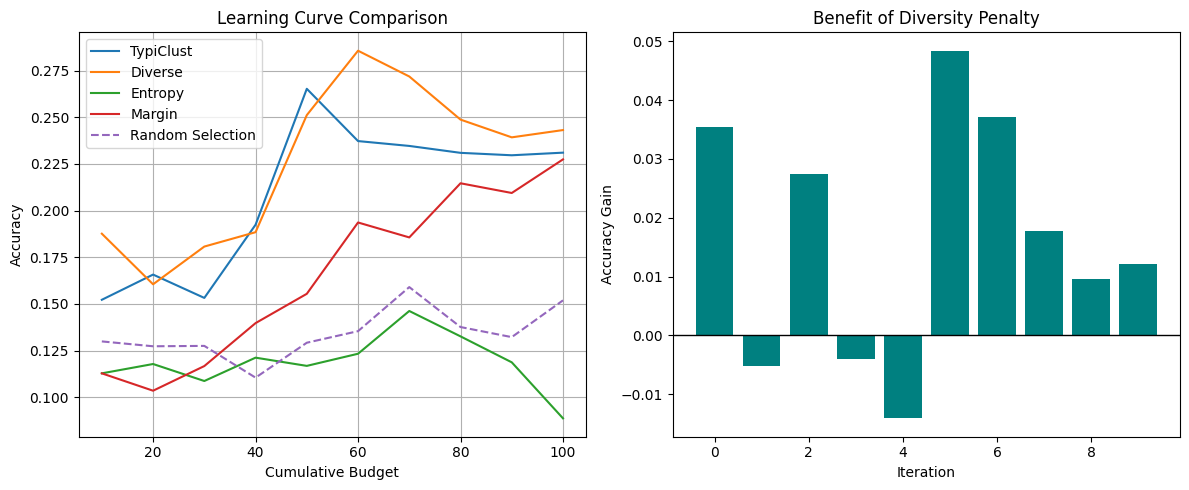

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

x = [(i+1)*10 for i in range(len(accuracies))]

plt.plot(x,accuracies, label="TypiClust")
plt.plot(x,accuracies_mod, label="Diverse")
plt.plot(x,accuracies_ent, label="Entropy")
plt.plot(x,accuracies_mar, label="Margin")
plt.plot(x,accuracies_rand, label='Random Selection', linestyle='--')
plt.xlabel("Cumulative Budget")
plt.ylabel("Accuracy")
plt.title("Learning Curve Comparison")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
diff = np.array(accuracies_mod) - np.array(accuracies)
plt.bar(range(len(diff)), diff, color='teal')
plt.axhline(0, color='black', lw=1)
plt.xlabel("Iteration")
plt.ylabel("Accuracy Gain")
plt.title("Benefit of Diversity Penalty")

plt.tight_layout()
plt.show()
